## Plot Abil Output

In [1]:
import cartopy.crs as ccrs
import cartopy as cart
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import xarray as xr
import os
import sys
from yaml import load, Loader
from matplotlib import cm
from matplotlib.colors import LogNorm
import matplotlib.ticker as ticker

In [2]:
with open('regressor.yml', 'r') as f:
    model_config = load(f, Loader=Loader)

run_name = 'ghux_na/'
file = '2026-04-30_mean_abundance'
ds = xr.open_dataset(model_config['local_root'] + model_config['path_out'] + run_name + 'posts/' + file + ".nc")

In [3]:
print(ds)

<xarray.Dataset>
Dimensions:                   (time: 12, depth: 6, lat: 26, lon: 61)
Coordinates:
  * time                      (time) int64 1 2 3 4 5 6 7 8 9 10 11 12
  * depth                     (depth) int64 0 5 10 15 20 25
  * lat                       (lat) int64 45 46 47 48 49 50 ... 66 67 68 69 70
  * lon                       (lon) int64 -60 -59 -58 -57 -56 ... -4 -3 -2 -1 0
Data variables:
    Gephyrocapsa huxleyi HET  (time, depth, lat, lon) float64 ...
Attributes:
    Conventions:  CF-1.5


### Create of map of surface Gephyrocapsa huxleyi HET abundance in April

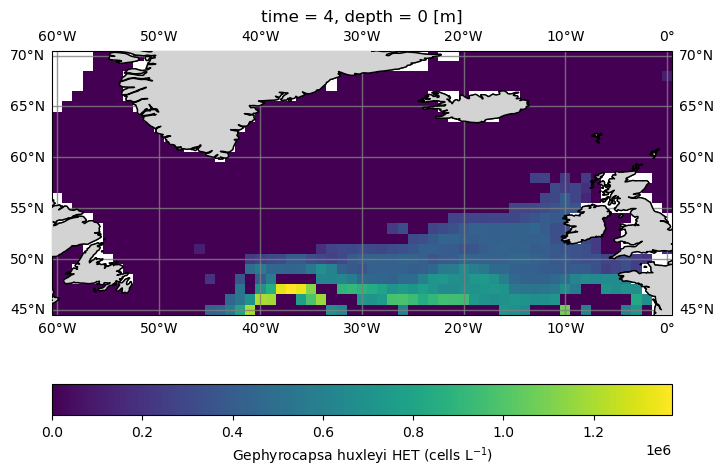

In [10]:
fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and land fill color
ax.coastlines()
ax.add_feature(cart.feature.LAND, 
               linewidth = 1, 
               zorder=3, 
               edgecolor='k', 
               facecolor="lightgray")

ax.gridlines(draw_labels=True, 
             linewidth=1,
             color='gray',
             alpha=0.8,
             linestyle='-',
             zorder=1
)
p = ds['Gephyrocapsa huxleyi HET'].sel(
    depth=0, 
    time=4
    ).plot(
        x='lon',
        y='lat',
        transform=ccrs.PlateCarree(),
        add_colorbar=False,)


cbar = plt.colorbar(p, 
                    location='bottom', 
                    label="Gephyrocapsa huxleyi HET (cells L$^{-1}$)")

### Create map of depth integrated PIC stock for Gephyrocapsa huxleyi HET

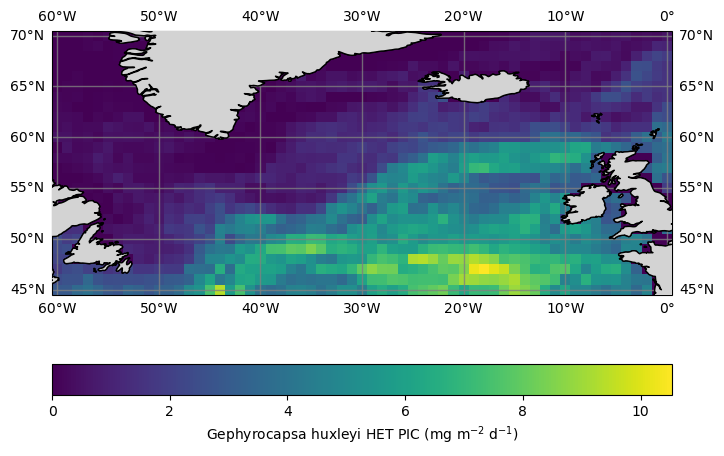

In [11]:
file = '2026-04-30_mean_pic'
ds = xr.open_dataset(model_config['local_root'] + model_config['path_out'] + run_name + 'posts/' + file + ".nc")

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add coastlines and land fill color
ax.coastlines()
ax.add_feature(cart.feature.LAND, 
               linewidth = 1, 
               zorder=3, 
               edgecolor='k', 
               facecolor="lightgray")

ax.gridlines(draw_labels=True, 
             linewidth=1,
             color='gray',
             alpha=0.8,
             linestyle='-',
             zorder=1
)

conversion_factor = 1e3 * 1e-9 # pg C L-1 to pg C m-3, pg C m-3 to mg C m-3
depth_width = 5
depth_integrated_pp = ds['Gephyrocapsa huxleyi HET'].sum(dim=["depth"]).mean(dim="time") * depth_width * conversion_factor

p = depth_integrated_pp.plot(
        x='lon',
        y='lat',
        transform=ccrs.PlateCarree(),
        add_colorbar=False,)


cbar = plt.colorbar(p, 
                    location='bottom', 
                    label="Gephyrocapsa huxleyi HET PIC (mg m$^{-2}$ d$^{-1}$)")

### Plot timeseries of production at a specific location
(add confidence intervals)

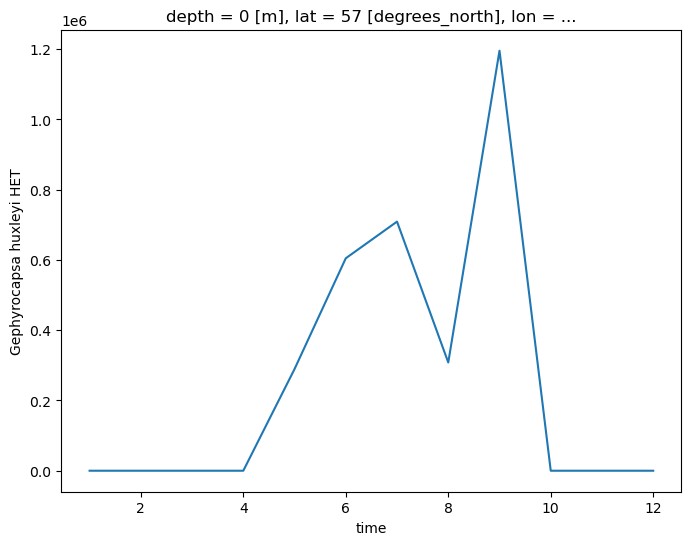

In [12]:
fig = plt.figure(figsize=(8, 6))

p = ds['Gephyrocapsa huxleyi HET'].sel(
    lat=57, 
    lon=-20,
    depth=0
    ).plot()